# 🎛️ Hyperparameter Tuner

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ml-engineering-toolkit/hyperparam-tuner/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ml-engineering-toolkit/hyperparam-tuner/demo.ipynb)

> Manual tuning is a person editing `n_estimators=100` to `200`, re-running a cell, and keeping whatever looked better. This tool wraps an **Optuna TPE search** around a **cross-validated** objective, so tuning is a budgeted, reproducible search that reports its **lift over the model's defaults** - not a lucky hand-edit.

**What this notebook covers**
1. A synthetic churn dataset with mixed column types
2. The default-model baseline score (what you'd ship untuned)
3. Running a budgeted Optuna TPE search
4. The lift over defaults + winning hyperparameters
5. Visualizing the optimization history (📈 best-so-far curve)
6. Try your own dataset / search space

## Step 1 - The problem

Every model ships with default hyperparameters chosen to be *reasonable*, not *optimal for your data*. Hand-tuning - nudge a number, re-run, keep what looks better - is slow, unreproducible, and quietly overfits to a single split.

The fix: define a search space once, let a smart sampler (Optuna's TPE) propose configurations, and score each one with **cross-validation** so we optimize generalization, not one lucky fold. We use a synthetic churn table so it runs with no downloads or API keys.

In [1]:
from __future__ import annotations

from tuner import make_sample_data, tune, summary_frame

df = make_sample_data()
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
print("churn rate:", round(df['churned'].mean(), 3))
df.head()

900 rows x 6 columns
churn rate: 0.698


,tenure_months,monthly_charges,support_tickets,plan,contract,churned
0,7,81.87,0,basic,yearly,1
1,55,66.72,4,basic,monthly,1
2,47,24.23,3,basic,monthly,1
3,32,93.21,1,pro,monthly,1
4,31,54.87,3,pro,monthly,0


## Step 2 - The baseline: model defaults

Before tuning anything, we need the score to beat. `tune()` first cross-validates a `RandomForestClassifier` with its out-of-the-box defaults. This is what you'd ship if you never tuned - and the honest reference for any improvement claim.

## Step 3 - Run the search

One call runs the whole thing: the default baseline, then an Optuna TPE study over `n_estimators`, `max_depth`, `min_samples_leaf`, and `max_features`, each configuration scored by 5-fold CV ROC AUC. The sampler learns from earlier trials to focus the budget on promising regions instead of blind grid points.

In [2]:
result = tune(df, target="churned", n_trials=30)
summary_frame(result)

,config,cv_roc_auc
0,Defaults,0.7008
1,Tuned (Optuna TPE),0.7658


## Step 4 - Read the lift

The number that matters is not the tuned score alone - it's the **lift over defaults**. A big lift means the defaults were leaving accuracy on the table; a tiny lift means they were already fine and you can stop tuning and spend the time on features instead.

In [3]:
print(f"Default CV ROC AUC : {result['default_score']:.4f}")
print(f"Tuned   CV ROC AUC : {result['best_score']:.4f}")
print(f"Lift               : +{result['lift']:.4f}  ({result['n_trials']} trials)")
print("\nBest hyperparameters:")
for k, v in result['best_params'].items():
    print(f"  {k:18s} = {v}")

Default CV ROC AUC : 0.7008
Tuned   CV ROC AUC : 0.7658
Lift               : +0.0650  (30 trials)

Best hyperparameters:
  n_estimators       = 400
  max_depth          = 4
  min_samples_leaf   = 6
  max_features       = 0.5564532903055841


## Step 5 - Visualize the optimization history 📈

Each dot is one trial's CV score; the red line is the **best score found so far**. A curve that climbs then flattens means the search has converged - extra budget past the plateau buys little. If it were still rising at the last trial, that's your signal to raise the budget.

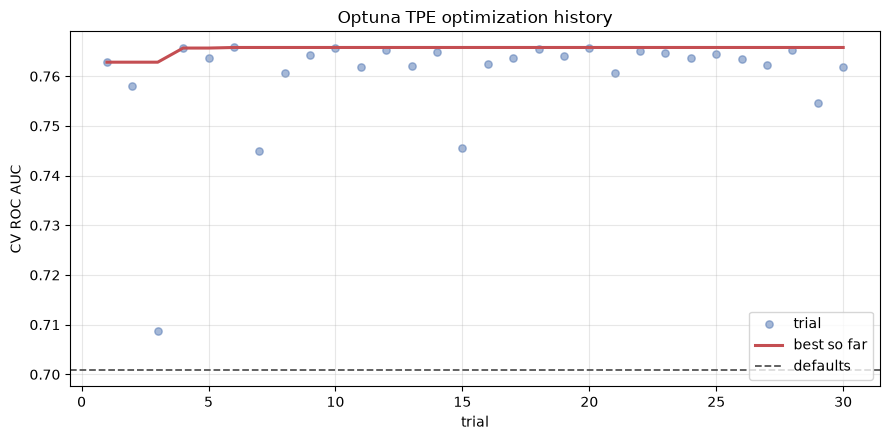

In [4]:
import matplotlib.pyplot as plt

hist = result["history"]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(hist["trial"], hist["value"], s=28, alpha=0.5, color="#4C72B0", label="trial")
ax.plot(hist["trial"], hist["best_so_far"], color="#C44E52", lw=2.2, label="best so far")
ax.axhline(result["default_score"], color="#555", ls="--", lw=1.3, label="defaults")
ax.set_xlabel("trial")
ax.set_ylabel("CV ROC AUC")
ax.set_title("Optuna TPE optimization history")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("optimization_history.png", dpi=120, bbox_inches="tight")
plt.show()

## Summary

| Item | Result |
|------|--------|
| Dataset | ~900 rows, mixed numeric + categorical, ~30% churn |
| Sampler | Optuna TPE (learns from prior trials), seeded for reproducibility |
| Objective | 5-fold stratified CV ROC AUC - optimizes generalization, not one split |
| Space | `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features` |
| Report | tuned score **and** lift over defaults, plus convergence curve |

Tuning is now a **budgeted, reproducible search with an honest baseline** - not a hand-edited cell.

## Try your own dataset / space

Point it at any CSV with a binary target. To change what's searched, edit `_suggest()` in `tuner.py` (or swap the estimator in `_pipe()`).

In [5]:
# import pandas as pd
# from tuner import tune, summary_frame
#
# my_df = pd.read_csv("your_data.csv")
# result = tune(my_df, target="your_binary_label", n_trials=50)
# summary_frame(result)
#
# # Widen or narrow the search space by editing _suggest() in tuner.py:
# #   "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=50),
# #   "max_depth":    trial.suggest_int("max_depth", 3, 30),

---
Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 73, ML Engineering Toolkit.

Prefer a UI? Run the Streamlit app to upload a CSV, set a trial budget, and watch the search beat the defaults:
```bash
pip install -r requirements.txt
streamlit run app.py
```